<a href="https://colab.research.google.com/github/Chiranjeevichethan/plant-disease-prediction-cnn/blob/main/Plant_Disease_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/siddhardhan23/plant-disease-prediction-cnn-deep-leanring-project.git

Cloning into 'plant-disease-prediction-cnn-deep-leanring-project'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 40 (delta 4), reused 1 (delta 1), pack-reused 34 (from 1)
Receiving objects: 100% (40/40), 331.88 KiB | 1.34 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [ ]:
%cd plant-disease-prediction-cnn-deep-leanring-project


/content/plant-disease-prediction-cnn-deep-leanring-project


In [ ]:
!ls


app  model_training_notebook  README.md  test_images


In [ ]:
!pip install -q kagglehub


In [ ]:
import kagglehub

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "abdallahalidev/plantvillage-dataset"
)

print("Dataset saved at:")
print(dataset_path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset saved at:
/kaggle/input/plantvillage-dataset


In [ ]:
import os

print(os.listdir(dataset_path))

['plantvillage dataset']


In [ ]:
print(os.listdir(dataset_path + "/plantvillage dataset"))

['segmented', 'grayscale', 'color']


In [ ]:
dataset_dir = dataset_path + "/plantvillage dataset/color"

print(dataset_dir)

/kaggle/input/plantvillage-dataset/plantvillage dataset/color


In [ ]:
print(os.listdir(dataset_dir)[:10])

['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot']


In [ ]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [ ]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [ ]:
class_names = train_ds.class_names

print(class_names)
print("Number of classes:", len(class_names))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

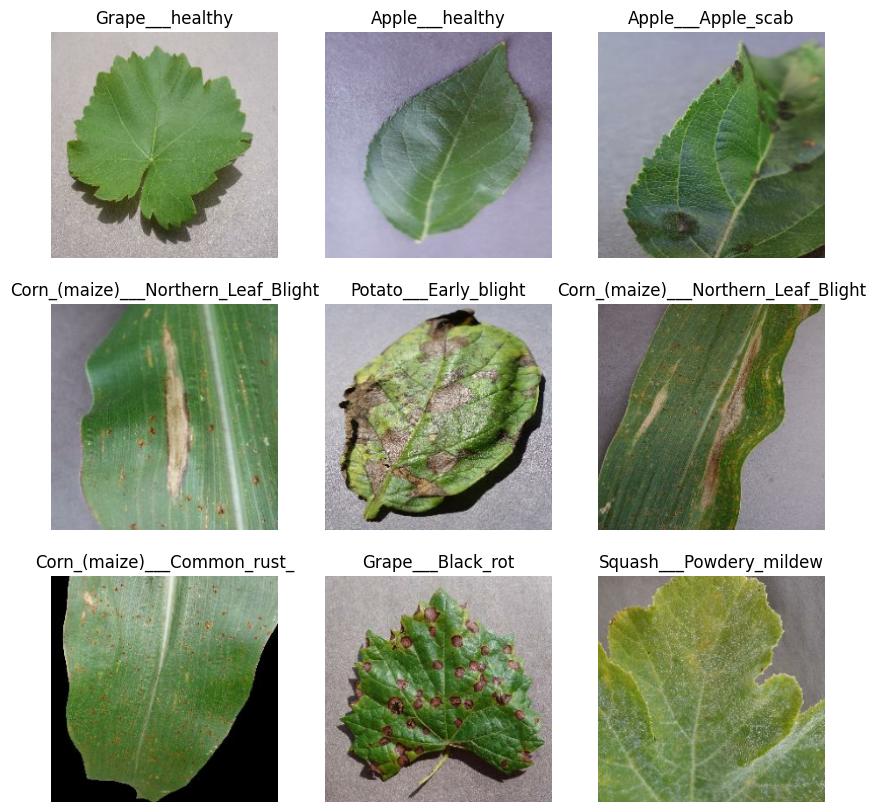

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,173,862 (42.62 MB)

 Trainable params: 11,173,862 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 186s 132ms/step - accuracy: 0.7218 - loss: 0.9732 - val_accuracy: 0.8691 - val_loss: 0.4192
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 81s 59ms/step - accuracy: 0.9076 - loss: 0.2892 - val_accuracy: 0.8973 - val_loss: 0.3420
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 83s 61ms/step - accuracy: 0.9484 - loss: 0.1528 - val_accuracy: 0.8990 - val_loss: 0.3978
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 149s 66ms/step - accuracy: 0.9668 - loss: 0.1036 - val_accuracy: 0.9057 - val_loss: 0.3874
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - accuracy: 0.9716 - loss: 0.0879 - val_accuracy: 0.9029 - val_loss: 0.4185
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 83s 61ms/step - accuracy: 0.9791 - loss: 0.0664 - val_accuracy: 0.8786 - val_loss: 0.5510
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 83s 61ms/step - accuracy: 0.9811 - loss: 0.0575 - val_accuracy: 0.8931 - val_loss: 0.5003
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 139s 60ms/step - accuracy: 0.98

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

340/340 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.8884 - loss: 0.6681
Validation Accuracy: 0.8884080648422241


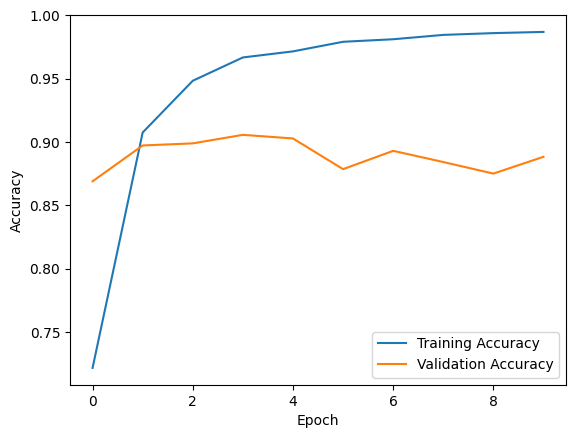

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

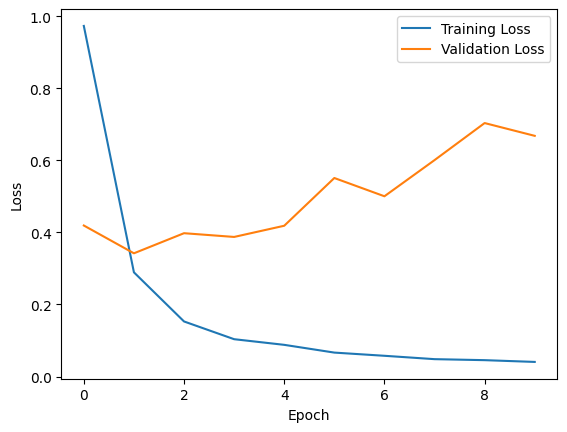

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model.save("plant_disease_model.keras")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print(os.listdir("test_images"))

['test_blueberry_healthy.jpg', 'test_potato_early_blight.jpg', 'test_apple_black_rot.JPG']


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

image_path = "test_images/AppleCedarRust1.JPG"

img = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)

predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = np.max(predictions[0]) * 100

plt.imshow(img)
plt.axis("off")
plt.title(predicted_class)
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

FileNotFoundError: [Errno 2] No such file or directory: 'test_images/AppleCedarRust1.JPG'

In [ ]:
import os

print(os.listdir("test_images"))

['test_blueberry_healthy.jpg', 'test_potato_early_blight.jpg', 'test_apple_black_rot.JPG']


In [ ]:
print(os.listdir("test_images"))

['test_blueberry_healthy.jpg', 'test_potato_early_blight.jpg', 'test_apple_black_rot.JPG']


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


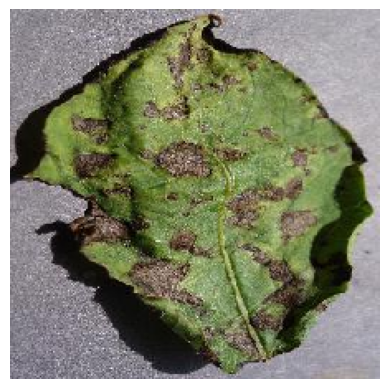

Predicted class: Potato___Early_blight
Confidence: 100.0 %


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

image_path = "test_images/test_potato_early_blight.jpg"

img = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)

predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]

confidence = np.max(predictions[0]) * 100

plt.imshow(img)
plt.axis("off")
plt.show()

print("Predicted class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

In [ ]:
image_path = "test_images/test_blueberry_healthy.jpg"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


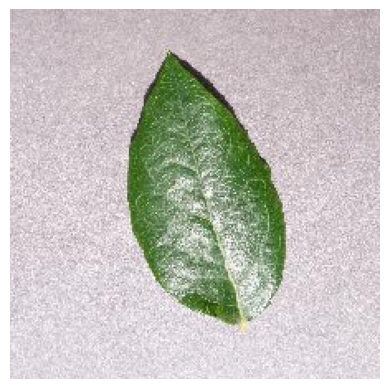

Predicted class: Blueberry___healthy
Confidence: 99.99 %


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

image_path = "test_images/test_blueberry_healthy.jpg"

img = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)

predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]

confidence = np.max(predictions[0]) * 100

plt.imshow(img)
plt.axis("off")
plt.show()

print("Predicted class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

In [ ]:
from google.colab import files
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for filename in uploaded.keys():

    img = tf.keras.utils.load_img(
        filename,
        target_size=(224, 224)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = np.max(predictions[0]) * 100

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("Predicted Disease:", predicted_class)
    print("Confidence:", round(confidence, 2), "%")

In [ ]:
from google.colab import files
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for filename in uploaded.keys():

    img = tf.keras.utils.load_img(
        filename,
        target_size=(224, 224)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = np.max(predictions[0]) * 100

    readable_name = predicted_class.replace("___", " - ").replace("_", " ")

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(readable_name)
    plt.show()

    print("🌿 Prediction:", readable_name)
    print("🎯 Confidence:", round(confidence, 2), "%")

KeyboardInterrupt: 

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np

def predict_leaf(image):
    if image is None:
        return "Please upload a leaf image.", {}

    # Resize image
    img = tf.image.resize(image, (224, 224))

    # Add batch dimension
    img_array = np.expand_dims(img, axis=0)

    # Predict
    predictions = model.predict(img_array, verbose=0)[0]

    # Get top 3 predictions
    top3_indices = np.argsort(predictions)[-3:][::-1]

    top3 = {}

    for index in top3_indices:
        class_name = class_names[index]
        readable_name = class_name.replace("___", " - ").replace("_", " ")
        top3[readable_name] = float(predictions[index])

    # Best prediction
    best_index = top3_indices[0]
    best_class = class_names[best_index]
    best_confidence = predictions[best_index] * 100

    readable_best = best_class.replace("___", " - ").replace("_", " ")

    result_text = (
        f"Prediction: {readable_best}\n"
        f"Confidence: {best_confidence:.2f}%"
    )

    return result_text, top3


with gr.Blocks(title="Plant Disease Prediction") as demo:

    gr.Markdown(
        """
        # 🌿 Plant Disease Prediction
        Upload a clear photo of a plant leaf.

        The CNN model will predict the most likely plant disease.
        """
    )

    with gr.Row():

        with gr.Column():
            image_input = gr.Image(
                type="numpy",
                label="Upload Leaf Image"
            )

            predict_button = gr.Button(
                "🔍 Predict Disease",
                variant="primary"
            )

        with gr.Column():

            result = gr.Textbox(
                label="Main Prediction",
                lines=3
            )

            probabilities = gr.Label(
                label="Top 3 Predictions",
                num_top_classes=3
            )

    predict_button.click(
        fn=predict_leaf,
        inputs=image_input,
        outputs=[result, probabilities]
    )


demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9940e492d5d4c72156.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
model.save("plant_disease_model.keras")

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("plant_disease_model.keras")

In [ ]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

In [ ]:
import json

with open("class_names.json", "r") as f:
    class_names = json.load(f)

In [ ]:
model.save("plant_disease_model.keras")

In [ ]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np
import json
import os
import textwrap
from PIL import Image, ImageDraw, ImageFont, ImageOps

# -------------------------
# Load model + class names
# -------------------------
model = tf.keras.models.load_model("plant_disease_model.keras")

with open("class_names.json", "r") as f:
    class_names = json.load(f)

dataset_dir = "/kaggle/input/plantvillage-dataset/plantvillage dataset/color"


# -------------------------
# Prediction function
# -------------------------
def predict_leaf(image_path):
    if image_path is None:
        return "Please select or upload an image.", {}

    img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]

    top3_indices = np.argsort(predictions)[-3:][::-1]

    top3 = {}
    for index in top3_indices:
        name = class_names[index]
        readable = name.replace("___", " - ").replace("_", " ")
        top3[readable] = float(predictions[index])

    best_index = top3_indices[0]
    best_name = class_names[best_index]
    best_confidence = predictions[best_index] * 100

    readable_best = best_name.replace("___", " - ").replace("_", " ")

    result = f"Prediction: {readable_best}\nConfidence: {best_confidence:.2f}%"

    return result, top3


# -------------------------
# Make preview images with text INSIDE image
# -------------------------
preview_dir = "preview_cards"
os.makedirs(preview_dir, exist_ok=True)

def make_preview(image_path, class_name, out_path, size=(220, 220)):
    img = Image.open(image_path).convert("RGB")
    img = ImageOps.fit(img, size, Image.Resampling.LANCZOS)

    draw = ImageDraw.Draw(img, "RGBA")

    # dark strip at bottom
    overlay_height = 52
    draw.rectangle(
        [(0, size[1] - overlay_height), (size[0], size[1])],
        fill=(0, 0, 0, 160)
    )

    font = ImageFont.load_default()

    wrapped_text = textwrap.fill(class_name, width=22)

    bbox = draw.multiline_textbbox((0, 0), wrapped_text, font=font, spacing=2)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    x = 8
    y = size[1] - overlay_height + (overlay_height - text_h) // 2

    draw.multiline_text(
        (x, y),
        wrapped_text,
        font=font,
        fill="white",
        spacing=2
    )

    img.save(out_path)


# -------------------------
# Get one sample from each class
# -------------------------
sample_items = []

for class_folder in sorted(os.listdir(dataset_dir)):
    folder_path = os.path.join(dataset_dir, class_folder)

    if os.path.isdir(folder_path):
        images = [
            f for f in os.listdir(folder_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        if images:
            original_path = os.path.join(folder_path, images[0])

            readable_class = class_folder.replace("___", " - ").replace("_", " ")

            preview_path = os.path.join(
                preview_dir,
                f"{class_folder}.jpg".replace("/", "_")
            )

            make_preview(original_path, readable_class, preview_path)

            sample_items.append({
                "original": original_path,
                "preview": preview_path,
                "class_name": readable_class
            })


# -------------------------
# Helper for rows
# -------------------------
def chunk_list(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]


# -------------------------
# Gradio UI
# -------------------------
with gr.Blocks(title="Plant Disease Prediction") as demo:

    gr.Markdown("# 🌿 Plant Disease Prediction")
    gr.Markdown("Upload your own image or choose a sample below.")

    image_input = gr.Image(
        type="filepath",
        label="Leaf Image"
    )

    predict_button = gr.Button("🔍 Predict Disease", variant="primary")

    result = gr.Textbox(label="Prediction", lines=3)

    top3_output = gr.Label(label="Top 3 Predictions", num_top_classes=3)

    gr.Markdown("## 🌱 Sample Images by Class")

    PER_ROW = 4   # change to 3 if you want 3 per row

    for row_items in chunk_list(sample_items, PER_ROW):
        with gr.Row():
            for item in row_items:
                with gr.Column():
                    sample_img = gr.Image(
                        value=item["preview"],
                        show_label=False,
                        interactive=False,
                        height=180,
                        width=180,
                        container=False
                    )

                    use_btn = gr.Button("Use this", size="sm")

                    use_btn.click(
                        fn=lambda p=item["original"]: p,
                        outputs=image_input
                    )

    predict_button.click(
        fn=predict_leaf,
        inputs=image_input,
        outputs=[result, top3_output]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://42d4167aa43e04185c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_folder = "/content/drive/MyDrive/Plant_Disease_Project"

os.makedirs(project_folder, exist_ok=True)

print("Project folder created!")

Project folder created!


In [ ]:
import shutil

shutil.copy(
    "plant_disease_model.keras",
    project_folder + "/plant_disease_model.keras"
)

print("Model saved to Google Drive!")

Model saved to Google Drive!


In [ ]:
shutil.copy(
    "class_names.json",
    project_folder + "/class_names.json"
)

print("Class names saved!")

Class names saved!
